What is LSTM? 

LSTM: Long Short Term Memory is a neural network architecture that allows RNNs to retain information over long sequences. It has a gradient highway where the previous layer's output is passed through and added to the processed input token. The cell state allows information to persist. There are 3 gating mechanisms that control the flow of information. A forget gate which decides whether to discard the information from the previous cell state. Input gate that determines which new information to store in the cell state. Output gate that decides what part of the cell state to output as the hidden state.

Gates that matter for volatility forecasting:
Forget gate is important as it allows us to just focus on the volatility numbers that matter such as sudden drops or sudden increases in prices.
Input gate is also important as it determines whether the current input is important.

We need to feed into LSTM log_returns as we need continuous data about the exact price change of a feature. We also need to add volatility as it captures the recent turbulence and variability the market is in right now. Using both it can give us a context of how the market is right now. Raw prices would not work as the values aren't normalized.

The tradeoffs of using a longer window would be that we have more data about how the feature moves along time. Thus, we can determine if an abrupt change in price or high volatility is common or uncommon. Using shorter windows allows us to determine the best case scenario at the moment like a greedy algorithm. The LSTM for bitcoin should lookback around 30 days.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader
import sys
import os

In [2]:
def create_sequences(df: pd.DataFrame, window_size: int):
    """Creates (X, y) sequence pairs from a DataFrame.
    X: (n_samples, window_size, n_features) — scaled input features
    y: (n_samples,) — raw volatility target (not scaled)
    """
    X_data = df[['log_returns', 'volatility']].values  # scaled features
    y_data = df['volatility_target'].values            # raw target
    X = [X_data[i:i+window_size] for i in range(len(df)-window_size)]
    y = [y_data[i+window_size] for i in range(len(df)-window_size)]
    return (
        torch.tensor(np.array(X), dtype=torch.float32),
        torch.tensor(np.array(y), dtype=torch.float32)
    )

In [3]:
# Load CSV
btc_df = pd.read_csv('../data/btc_data.csv', index_col='Date', parse_dates=True)

# Raw splits (before scaling)
train_raw = btc_df.loc["2018-01-31":"2022-12-31"]
val_raw   = btc_df.loc["2023-01-01":"2023-12-31"]
test_raw  = btc_df.loc["2024-01-01":"2024-12-31"]

print(f"Train: {len(train_raw)} rows | Val: {len(val_raw)} rows | Test: {len(test_raw)} rows")

Train: 1796 rows | Val: 365 rows | Test: 365 rows


In [4]:
# Scale input features — fit ONLY on train, transform all splits
# Target (volatility) is NOT scaled so evaluation metrics stay interpretable
feature_scaler = StandardScaler()
feature_scaler.fit(train_raw[['log_returns', 'volatility']])

def apply_scaling(df, scaler):
    df_scaled = df.copy()
    df_scaled[['log_returns', 'volatility']] = scaler.transform(df[['log_returns', 'volatility']])
    df_scaled['volatility_target'] = df['volatility']  # raw target, unscaled
    return df_scaled

train = apply_scaling(train_raw, feature_scaler)
val   = apply_scaling(val_raw,   feature_scaler)
test  = apply_scaling(test_raw,  feature_scaler)

print("Scaling applied. Feature means (should be ~0 for train):")
print(train[['log_returns', 'volatility']].mean())

Scaling applied. Feature means (should be ~0 for train):
log_returns    2.373751e-17
volatility    -1.978126e-16
dtype: float64


In [5]:
# Create sequence datasets
X_train, y_train = create_sequences(train, window_size=30)
X_val,   y_val   = create_sequences(val,   window_size=30)
X_test,  y_test  = create_sequences(test,  window_size=30)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")

X_train shape: torch.Size([1766, 30, 2]) | y_train shape: torch.Size([1766])


In [6]:
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from models.lstm import LSTMModel

In [7]:
# DataLoaders — shuffle only training set
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

In [8]:
def train_and_validate(model, train_loader, val_loader, optimizer, loss_fn, save_path, num_epochs=50):
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
        model.eval()
        print("Loaded from checkpoint")
    else:
        print("Training from scratch")
        train_losses = []
        val_losses   = []

        for epoch in range(num_epochs):
            # --- Train ---
            model.train()
            running_train_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch = X_batch.float()
                y_batch = y_batch.float().view(-1, 1)
                pred = model(X_batch)
                loss = loss_fn(pred, y_batch)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                running_train_loss += loss.item()
            avg_train_loss = running_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # --- Validate ---
            model.eval()
            running_val_loss = 0
            with torch.no_grad():
                for X_b_val, y_b_val in val_loader:
                    X_b_val = X_b_val.float()
                    y_b_val = y_b_val.float().view(-1, 1)
                    val_pred = model(X_b_val)
                    v_loss = loss_fn(val_pred, y_b_val)
                    running_val_loss += v_loss.item()
            avg_val_loss = running_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}] | "
                      f"Train Loss: {avg_train_loss:.6f} | "
                      f"Val Loss: {avg_val_loss:.6f}")

        torch.save(model.state_dict(), save_path)

    return model

In [14]:
def evaluate_model(model, test_loader, test_raw, window_size=30):
    """Run inference on test set and compute MSE and MAE.
    Predictions are in original volatility units (target was never scaled).
    """
    model.eval()
    predictions = []
    with torch.no_grad():
        for X_btest, _ in test_loader:
            pred = model(X_btest.float())
            predictions.append(pred)

    lstm_forecast = torch.cat(predictions).cpu().numpy().flatten()
    actual        = test_raw['volatility'].iloc[window_size:].values
    forecast_index = test_raw.index[window_size:]

    results = pd.DataFrame(
        {'actual': actual, 'lstm_forecast': lstm_forecast},
        index=forecast_index
    )

    mse = mean_squared_error(results['actual'], results['lstm_forecast'])
    mae = mean_absolute_error(results['actual'], results['lstm_forecast'])
    print(f"MSE: {mse:.8f} | MAE: {mae:.6f}")
    
    #Directional Accuracy
    num_dates = len(results)
    actual_diff = np.sign(results['actual'].diff().dropna())
    pred_diff = np.sign(results['lstm_forecast'].diff().dropna())
    correct_preds = actual_diff == pred_diff
    directional_accuracy = (correct_preds).mean()
    print(f"Correct predictions: {sum(correct_preds)}")
    print(f"Total days: {num_dates}")
    print(f"Directional Accuracy: {directional_accuracy *100}")
    
    return results

In [15]:
# Train MSE-loss LSTM
save_path = '../models/mse_lstm_model.pth'

model     = LSTMModel(input_size=2, hidden_size=64, num_layers=2, dropout=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    save_path=save_path
)

# Evaluate — pass test_raw so actual values are in original units
results = evaluate_model(model, test_loader, test_raw)

Training from scratch
Epoch [1/50] | Train Loss: 0.000800 | Val Loss: 0.000187
Epoch [10/50] | Train Loss: 0.000014 | Val Loss: 0.000002
Epoch [20/50] | Train Loss: 0.000011 | Val Loss: 0.000003
Epoch [30/50] | Train Loss: 0.000010 | Val Loss: 0.000002
Epoch [40/50] | Train Loss: 0.000010 | Val Loss: 0.000002
Epoch [50/50] | Train Loss: 0.000010 | Val Loss: 0.000003
MSE: 0.00000256 | MAE: 0.001136
Correct predictions: 164
Total days: 335
Directional Accuracy: 49.101796407185624


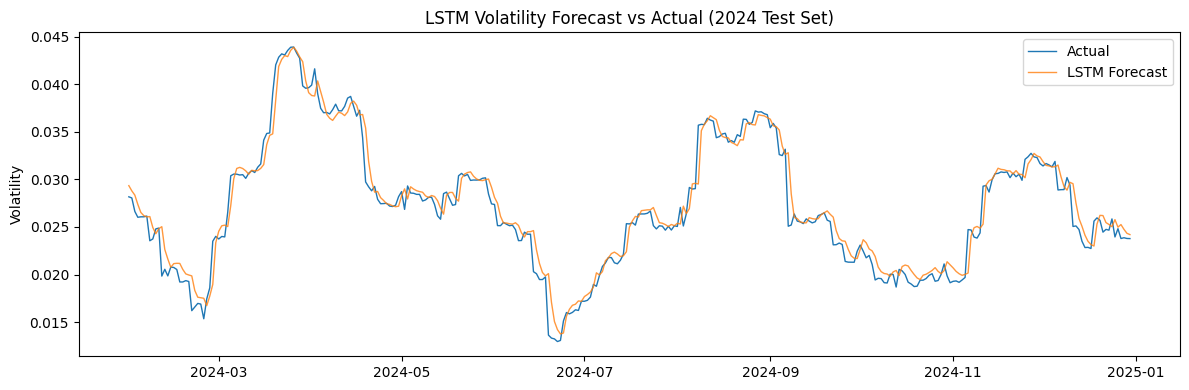

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(results.index, results['actual'],        label='Actual',          linewidth=1)
ax.plot(results.index, results['lstm_forecast'], label='LSTM Forecast',   linewidth=1, alpha=0.8)
ax.set_title('LSTM Volatility Forecast vs Actual (2024 Test Set)')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()

LSTM results: model collapses to mean prediction on realized_variance (target too noisy) and lag-1 prediction on rolling volatility (target too smooth/persistent). Neither alternative loss functions nor additional features resolved this. Fundamental limitation is that LSTM sequential processing doesn't capture which historical days are most relevant. Overall LSTM resulted in worse than random directional accuracy but improved MSE and MAE scores. 